# Part 2 — Permutation & Augmentation Experiments

Compare identity vs random permutations and simple augmentations on a tiny subset.

## Set Up

### General imports

In [1]:
# General imports
import os, sys
from pathlib import Path

# Image processing imports
import torch
from torchvision import transforms

### Local imports

In [2]:
cwd = Path.cwd()

if (cwd / "src").exists():
    repo_root = cwd
elif (cwd.parent.parent / "src").exists():
    repo_root = cwd.parent.parent
else:
    raise RuntimeError("Cannot find repo root containing src/")

sys.path.insert(0, str(repo_root.resolve()))

In [3]:
from src.utils import notebook_helpers as nh
from src.utils.permutations import identity_permutation, generate_permutations
from src.utils.metrics import average_displacement, adjacency_preservation, displacement_entropy
from src.models.model import get_model

/Users/royrubin/opt/anaconda3/envs/mlds_dogs_vs_cats/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Global Definitions

In [4]:
MODE = 'quick'
GRID = 3
DL_COUNT = 16
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Code

/Users/royrubin/opt/anaconda3/envs/mlds_dogs_vs_cats/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/royrubin/opt/anaconda3/envs/mlds_dogs_vs_cats/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Permutation metrics: avg_disp=0.613 adj_pres=0.500 entropy=1.352


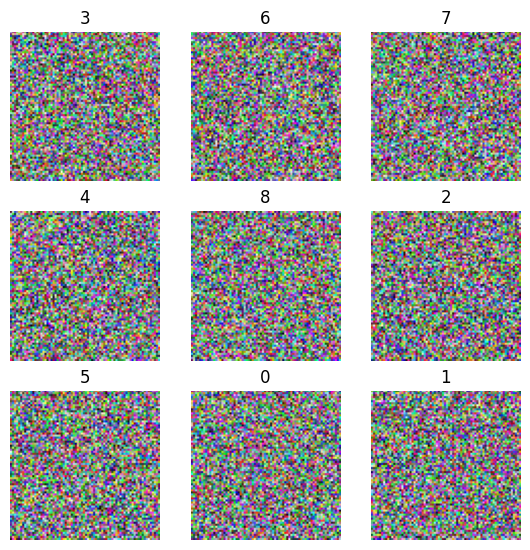

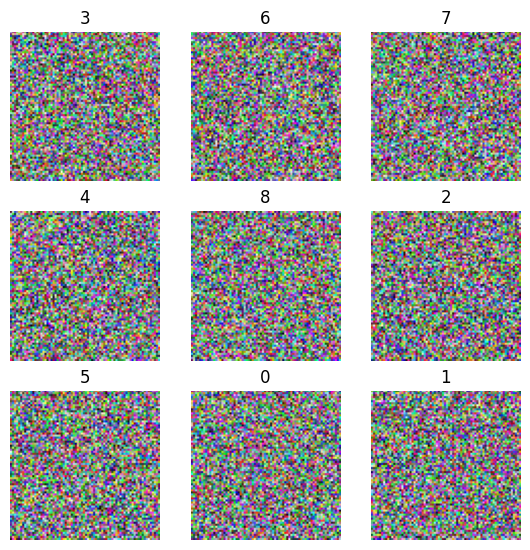

In [5]:
# Prepare dataloader (synthetic)
dl, ds = nh.build_tiny_dataloader(sample_paths=None, grid=GRID, batch_size=8, use_synthetic=True, synthetic_count=DL_COUNT)
# Prepare a small model
model = get_model('resnet18', num_classes=2, pretrained=False)
# Compute a random permutation and metrics for it
perm = generate_permutations(GRID, 1, seed=42)[0]
print('Permutation metrics: avg_disp=%.3f adj_pres=%.3f entropy=%.3f' % (
    average_displacement(perm, GRID), adjacency_preservation(perm, GRID), displacement_entropy(perm, GRID)))

# Visualize tiles for synthetic sample
imgs = nh.create_synthetic_rgb_images(1, size=(224,224), seed=0)
tiles = nh.split_into_tiles(imgs[0], GRID)
fig = nh.visualize_tiles(tiles, permutation=perm)
display(fig)